#### **Data Investigation — NASA C-MAPSS FD001**

The goal of this notebook is to understand the NASA C-MAPSS FD001 dataset before building any machine learning model.

The dataset contains simulated aircraft engine run-to-failure trajectories. Each engine is observed over multiple operating cycles, with sensor measurements recorded at each cycle.

Before modeling, we will investigate:

- the structure of the training and test data,
- the number of engines and operating cycles,
- data quality,
- sensor variability,
- operational settings, and
- whether sensor trajectories show visible degradation patterns.

The findings from this investigation will guide our preprocessing and feature-engineering decisions in the next stages of the project.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "C-MAPSS"

TRAIN_PATH = DATA_DIR / "train_FD001.txt"
TEST_PATH = DATA_DIR / "test_FD001.txt"
RUL_PATH = DATA_DIR / "RUL_FD001.txt"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: c:\Users\User\Desktop\jet-engine-predictive-maintenance
Data directory: c:\Users\User\Desktop\jet-engine-predictive-maintenance\data\raw\C-MAPSS


In [5]:
print("Train exists:", TRAIN_PATH.exists())
print("Test exists:", TEST_PATH.exists())
print("RUL exists:", RUL_PATH.exists())

Train exists: True
Test exists: True
RUL exists: True


In [6]:
with open(TRAIN_PATH, "r") as f:
    for _ in range(5):
        print(repr(f.readline()))

'1 1 -0.0007 -0.0004 100.0 518.67 641.82 1589.70 1400.60 14.62 21.61 554.36 2388.06 9046.19 1.30 47.47 521.66 2388.02 8138.62 8.4195 0.03 392 2388 100.00 39.06 23.4190  \n'
'1 2 0.0019 -0.0003 100.0 518.67 642.15 1591.82 1403.14 14.62 21.61 553.75 2388.04 9044.07 1.30 47.49 522.28 2388.07 8131.49 8.4318 0.03 392 2388 100.00 39.00 23.4236  \n'
'1 3 -0.0043 0.0003 100.0 518.67 642.35 1587.99 1404.20 14.62 21.61 554.26 2388.08 9052.94 1.30 47.27 522.42 2388.03 8133.23 8.4178 0.03 390 2388 100.00 38.95 23.3442  \n'
'1 4 0.0007 0.0000 100.0 518.67 642.35 1582.79 1401.87 14.62 21.61 554.45 2388.11 9049.48 1.30 47.13 522.86 2388.08 8133.83 8.3682 0.03 392 2388 100.00 38.88 23.3739  \n'
'1 5 -0.0019 -0.0002 100.0 518.67 642.37 1582.85 1406.22 14.62 21.61 554.00 2388.06 9055.15 1.30 47.28 522.19 2388.04 8133.80 8.4294 0.03 393 2388 100.00 38.90 23.4044  \n'


In [7]:
with open(RUL_PATH, "r") as f:
    for _ in range(5):
        print(repr(f.readline()))

'112 \n'
'98 \n'
'69 \n'
'82 \n'
'91 \n'


#### **Raw Dataset Format**

The FD001 files are provided as space-separated text files rather than standard CSV files with column headers.

Before loading the data into Pandas, I inspected a few raw lines from the training and RUL files to understand their structure.

The training data contains:

- engine/unit identifier,
- operating cycle,
- three operational settings, and
- 21 sensor measurements.

The RUL file contains one remaining-useful-life value for each test engine.

### **Assigning Column Names**

The raw FD001 files do not contain descriptive column names. I therefore created names based on the known dataset structure.

Each observation contains 26 columns:

- 1 engine identifier (`unit`)
- 1 operating cycle (`cycle`)
- 3 operational settings
- 21 sensor measurements

The sensor columns are named `sensor_1` through `sensor_21` for consistent processing throughout the project.

In [8]:
column_names = (
    ["unit", "cycle", "setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

print(len(column_names))
print(column_names)

26
['unit', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


#### **Loading the Training, Test and RUL Data**

The dataset is divided into three files:

- **Training data:** complete run-to-failure histories for 100 engines.
- **Test data:** truncated histories for 100 engines.
- **RUL data:** the true remaining useful life of each test engine at the end of its observed test trajectory.

The training data will be used to learn degradation patterns, while the test trajectories will later be used to evaluate the final RUL prediction model.

In [9]:
train_df = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    names=column_names
)

print(train_df.shape)
train_df.head()

(20631, 26)


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [10]:
test_df = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
    names=column_names
)

print(test_df.shape)
test_df.head()

(13096, 26)


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [11]:
rul_df = pd.read_csv(
    RUL_PATH,
    header=None,
    names=["RUL"]
)

print(rul_df.shape)
rul_df.head()

(100, 1)


,RUL
0,112
1,98
2,69
3,82
4,91


#### **Engine Population and Lifecycle Analysis**

The dataset contains repeated observations from individual engines rather than independent observations from different engines.

Therefore, it is important to understand how many engines are present and how long each engine was observed during training.

I calculate the maximum cycle reached by each engine to examine the variation in engine lifetimes.

In [12]:
print("Training engines:", train_df["unit"].nunique())
print("Test engines:", test_df["unit"].nunique())

print("First training engine:", train_df["unit"].min())
print("Last training engine:", train_df["unit"].max())

Training engines: 100
Test engines: 100
First training engine: 1
Last training engine: 100


In [13]:
train_lifetimes = train_df.groupby("unit")["cycle"].max()

print(train_lifetimes.describe())

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [14]:
print(train_lifetimes.head(10))

unit
1     192
2     287
3     179
4     189
5     269
6     188
7     259
8     150
9     201
10    222
Name: cycle, dtype: int64


#### **Data Quality Checks**

Before performing feature engineering or model training, I checked the training dataset for missing values and duplicate rows.

These checks help determine whether additional data-cleaning steps are required before modeling.

In [15]:
print("Missing values:", train_df.isna().sum().sum())
print("Duplicate rows:", train_df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


#### **Sensor Variability Investigation**

The FD001 dataset contains 21 sensor measurements.

Not every sensor necessarily provides useful information. A sensor that remains constant throughout the dataset cannot help a machine learning model distinguish between different engine conditions.

Therefore, I calculated the variance of each sensor to identify constant and near-constant measurements.

In [16]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

print(sensor_columns)
print("Number of sensors:", len(sensor_columns))

['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
Number of sensors: 21


In [17]:
sensor_variance = train_df[sensor_columns].var()

sensor_variance

sensor_1     0.000000e+00
sensor_2     2.500533e-01
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_7     7.833883e-01
sensor_8     5.038938e-03
sensor_9     4.876536e+02
sensor_10    0.000000e+00
sensor_11    7.133568e-02
sensor_12    5.439850e-01
sensor_13    5.172330e-03
sensor_14    3.639005e+02
sensor_15    1.406628e-03
sensor_16    1.203765e-35
sensor_17    2.398667e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_20    3.266927e-02
sensor_21    1.171825e-02
dtype: float64

In [18]:
sensor_variance.sort_values()

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.203765e-35
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64

##### **Constant Sensors**

Sensors with exactly zero variance have the same value for every observation in the training dataset.

The investigation identified:

- `sensor_1`
- `sensor_10`
- `sensor_18`
- `sensor_19`

These sensors provide no variation across the training observations and will therefore be considered for removal during preprocessing.

In [19]:
constant_sensors = sensor_variance[sensor_variance == 0].index.tolist()

print("Constant sensors:")
print(constant_sensors)
print("Number of constant sensors:", len(constant_sensors))

Constant sensors:
['sensor_1', 'sensor_10', 'sensor_18', 'sensor_19']
Number of constant sensors: 4


##### **Near-Constant Sensors**

Some sensors have extremely small variance without being mathematically constant.

For example, `sensor_5`, `sensor_16`, and `sensor_6` show very little variation.

Rather than automatically removing these sensors based only on their variance, I will investigate their unique values and behavior before making a final feature-selection decision.

In [20]:
sensor_variance.sort_values().head(10)

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.203765e-35
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
dtype: float64

#### **Operational Settings Investigation**

In addition to sensor measurements, each observation contains three operational settings.

These settings describe the operating conditions under which the sensor measurements were recorded.

I examine their statistical distribution and number of unique values to determine whether they provide meaningful variation in FD001.

In [21]:
for sensor in sensor_variance.sort_values().head(10).index:
    print(
        sensor,
        "unique values:",
        train_df[sensor].nunique(),
        "variance:",
        sensor_variance[sensor]
    )

sensor_1 unique values: 1 variance: 0.0
sensor_10 unique values: 1 variance: 0.0
sensor_19 unique values: 1 variance: 0.0
sensor_18 unique values: 1 variance: 0.0
sensor_16 unique values: 1 variance: 1.203764562610672e-35
sensor_5 unique values: 1 variance: 2.840036917509108e-29
sensor_6 unique values: 2 variance: 1.9292790877285376e-06
sensor_15 unique values: 1918 variance: 0.001406627871778449
sensor_8 unique values: 53 variance: 0.005038938213373842
sensor_13 unique values: 56 variance: 0.005172330435259189


In [22]:
settings = ["setting_1", "setting_2", "setting_3"]

print(train_df[settings].describe().T)

             count        mean       std       min       25%    50%       75%  \
setting_1  20631.0   -0.000009  0.002187   -0.0087   -0.0015    0.0    0.0015   
setting_2  20631.0    0.000002  0.000293   -0.0006   -0.0002    0.0    0.0003   
setting_3  20631.0  100.000000  0.000000  100.0000  100.0000  100.0  100.0000   

                max  
setting_1    0.0087  
setting_2    0.0006  
setting_3  100.0000  


In [23]:
print("Unique values:")
print(train_df[settings].nunique())

Unique values:
setting_1    158
setting_2     13
setting_3      1
dtype: int64



`setting_3` has only one unique value and therefore does not vary across the FD001 training data.

This makes it a candidate for removal during preprocessing, similar to the constant sensors identified above.

#### **Visual Investigation of Sensor Degradation**

Variance alone does not tell us whether a sensor is useful for predictive maintenance.

A useful sensor may have substantial noise while still showing a gradual change as an engine approaches the end of its useful life.

To investigate this behavior, I plotted selected sensor trajectories against operating cycle for individual engines.

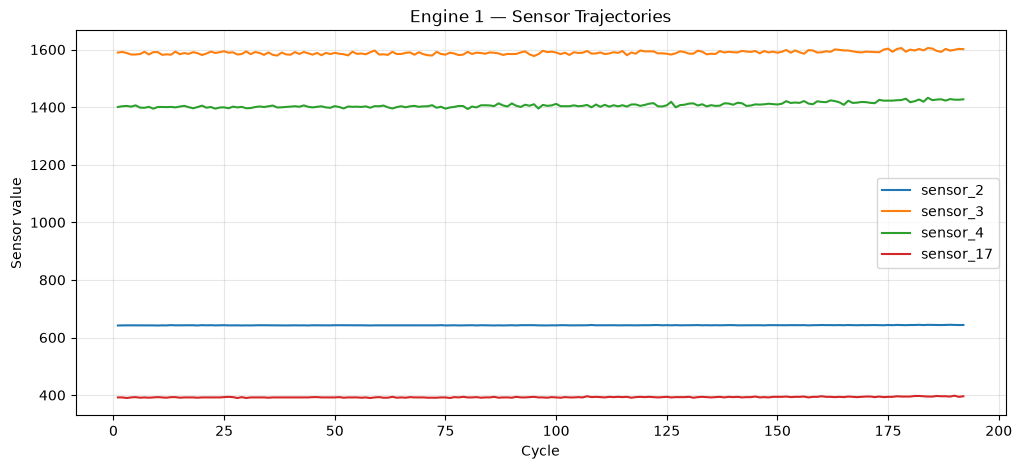

In [35]:
engine_1 = train_df[train_df["unit"] == 1]

plt.figure(figsize=(12, 5))

for sensor in ["sensor_2", "sensor_3", "sensor_4" , "sensor_17"]:
    plt.plot(
        engine_1["cycle"],
        engine_1[sensor],
        label=sensor
    )

plt.xlabel("Cycle")
plt.ylabel("Sensor value")
plt.title("Engine 1 — Sensor Trajectories")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


- The sensor trajectories fluctuate from cycle to cycle, but some sensors show an overall change as the engine progresses through its lifecycle.

- This suggests that degradation is not represented by a perfectly smooth signal. Instead, useful degradation information may be embedded within noisy sensor measurements.



#### **Comparing Sensor Behavior Across Engines**

A degradation pattern observed in one engine may not necessarily generalize to other engines.

To investigate this, I compared Sensor 3 across five engines with different lifecycle lengths.

The purpose is not to prove that Sensor 3 alone is predictive, but to determine whether similar lifecycle trends can be observed across multiple engines.

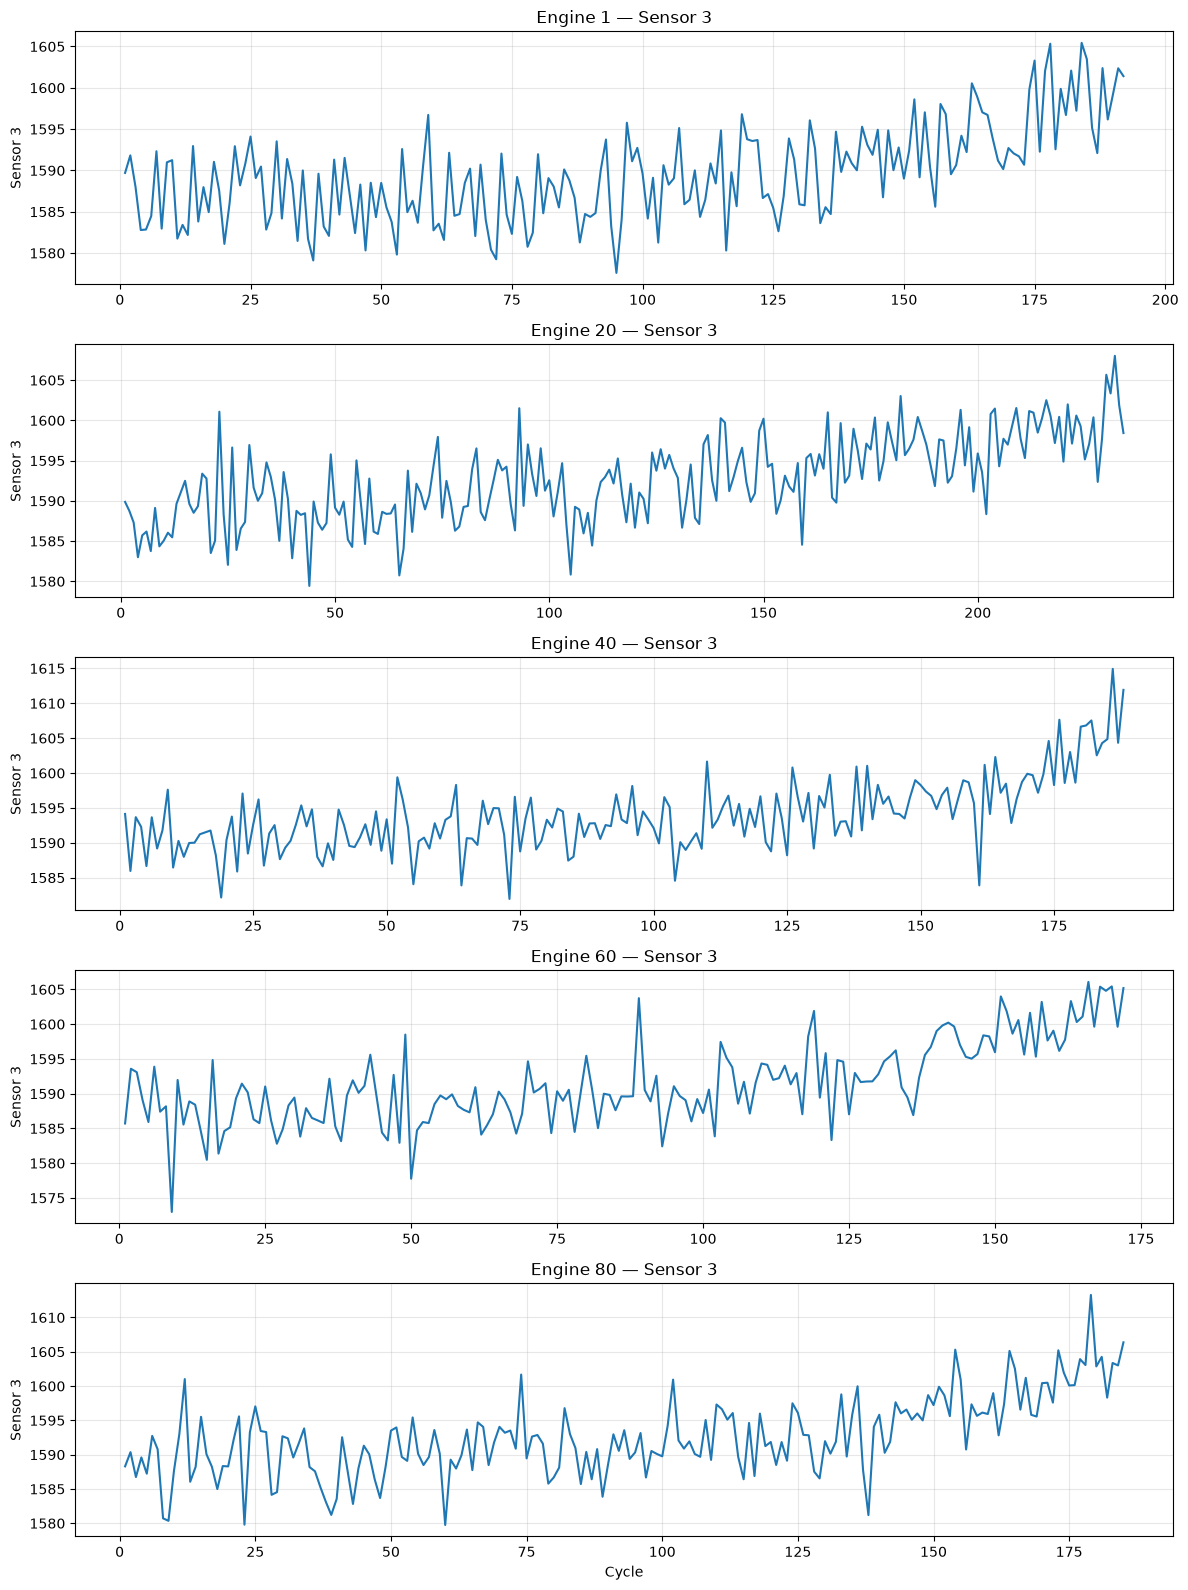

In [25]:
sample_engines = [1, 20, 40, 60, 80]

fig, axes = plt.subplots(
    len(sample_engines),
    1,
    figsize=(12, 16),
    sharex=False
)

for ax, engine_id in zip(axes, sample_engines):

    engine_data = train_df[train_df["unit"] == engine_id]

    ax.plot(
        engine_data["cycle"],
        engine_data["sensor_3"]
    )

    ax.set_title(f"Engine {engine_id} — Sensor 3")
    ax.set_ylabel("Sensor 3")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Cycle")

plt.tight_layout()
plt.show()


- Sensor 3 shows considerable cycle-to-cycle variation across all five engines. However, the later portions of several trajectories show an upward movement compared with their earlier cycles.

- The trend is therefore noisy rather than perfectly monotonic.

- This indicates that degradation information may be present in the sensor trajectory but may need to be extracted through feature engineering rather than relying on individual raw measurements alone.

### **Data Investigation Summary**

The initial investigation provided several important findings that will guide the next stage of the project.

#### Dataset

- FD001 contains 100 training engines and 100 test engines.
- The training set contains 20,631 observations and 26 columns.
- Each observation represents an engine at a particular operating cycle.
- Training engines have different lifecycle lengths, ranging from 128 to 362 cycles.

#### Data Quality

- No missing values were found in the training data.
- No duplicate rows were found.

#### Feature Investigation

- The dataset contains 21 sensor measurements.
- Four sensors (`sensor_1`, `sensor_10`, `sensor_18`, and `sensor_19`) have zero variance.
- Several additional sensors have extremely low variance and require further consideration.
- `setting_3` is constant in FD001.

#### Degradation Behavior

Sensor trajectories contain substantial noise, but some sensors show changes as engines progress through their lifecycle. This suggests that raw sensor values alone may not fully capture degradation and motivates the use of temporal feature engineering.

These findings will be used to guide preprocessing and feature engineering before training the RUL prediction models.